In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/post natal data.csv")

In [3]:
df.head()

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [4]:
df = df.dropna()

In [5]:
df = df.drop(['Timestamp'], axis = 1)

In [6]:
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


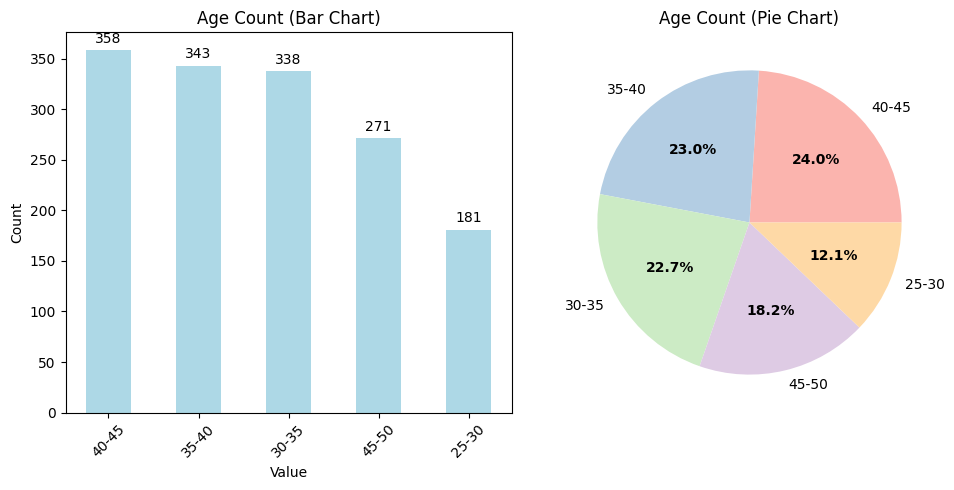

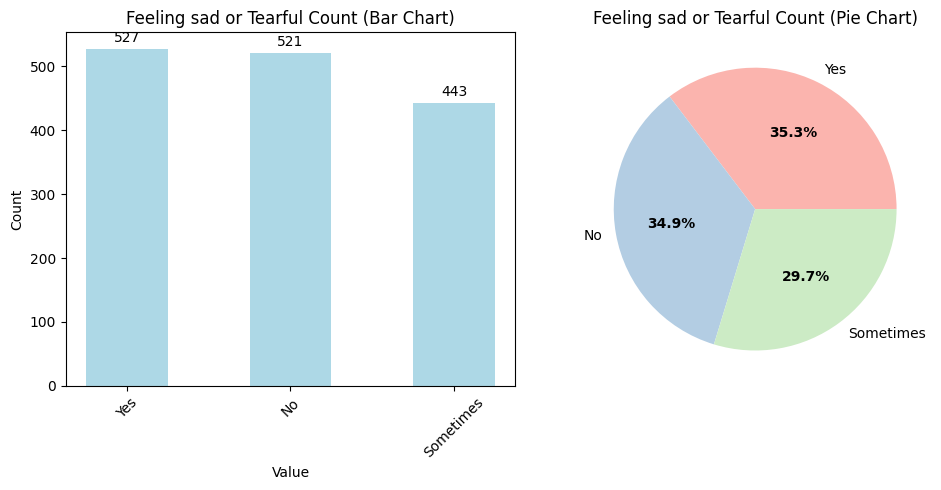

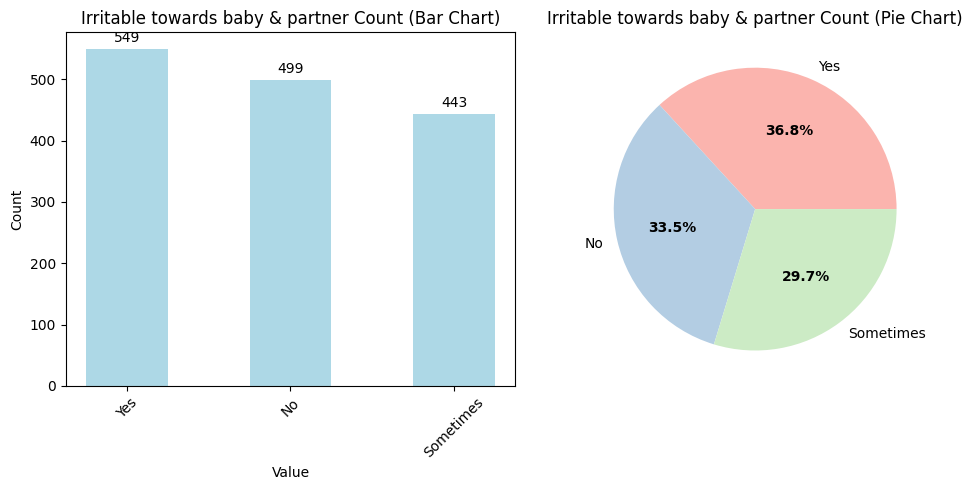

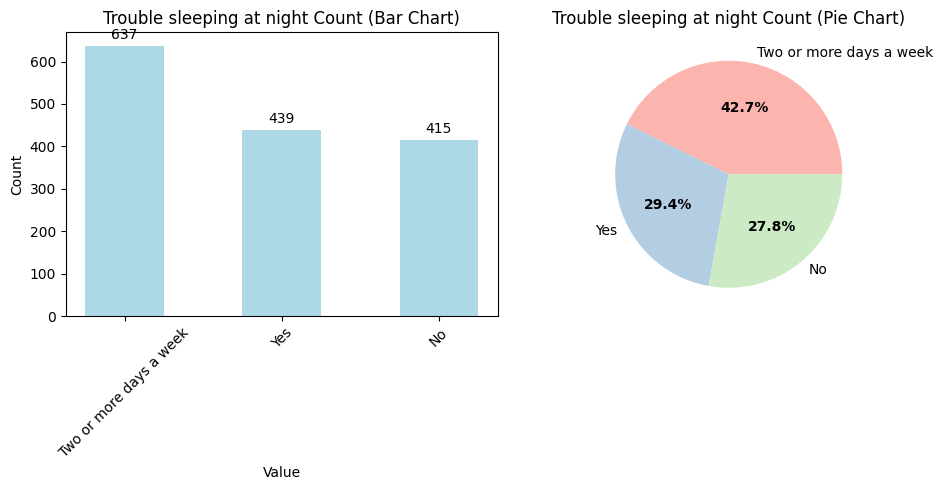

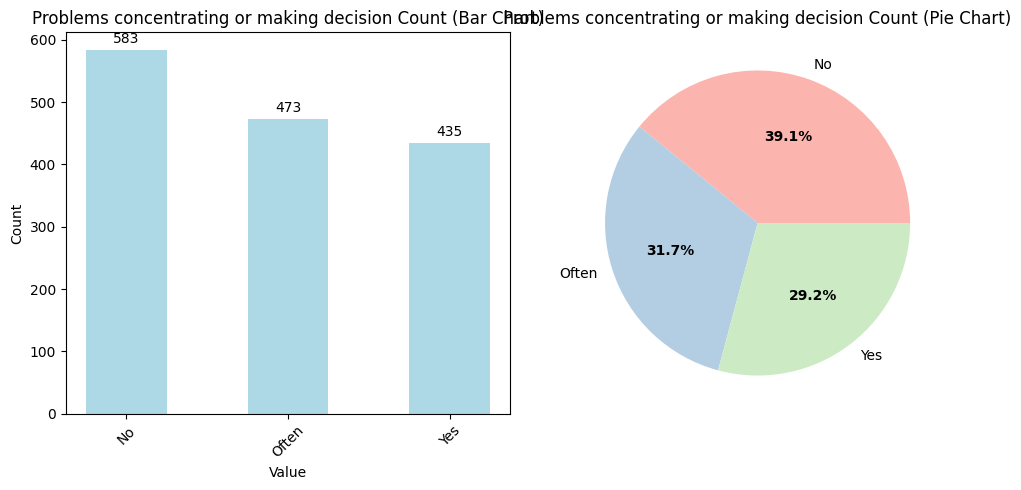

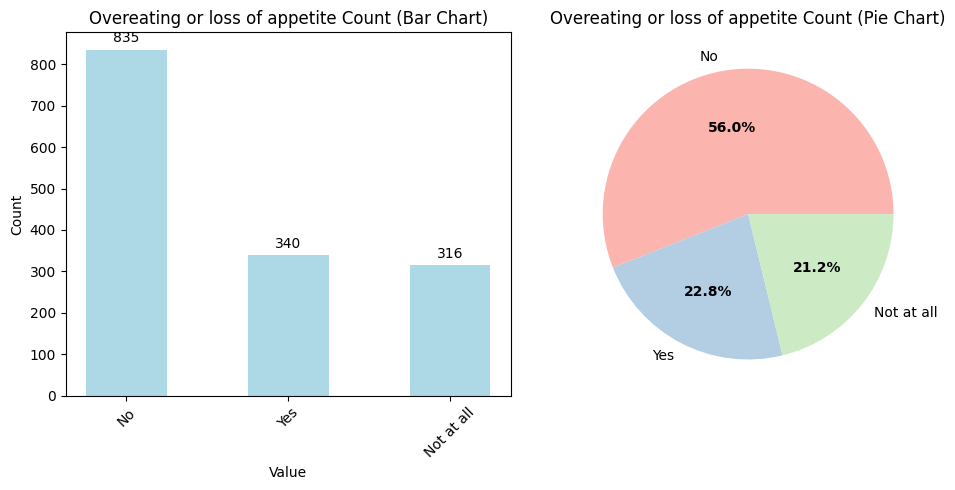

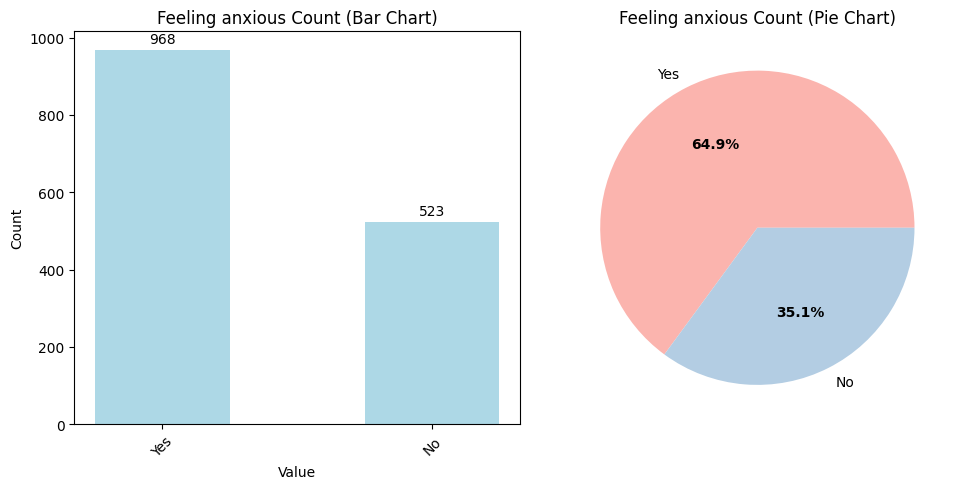

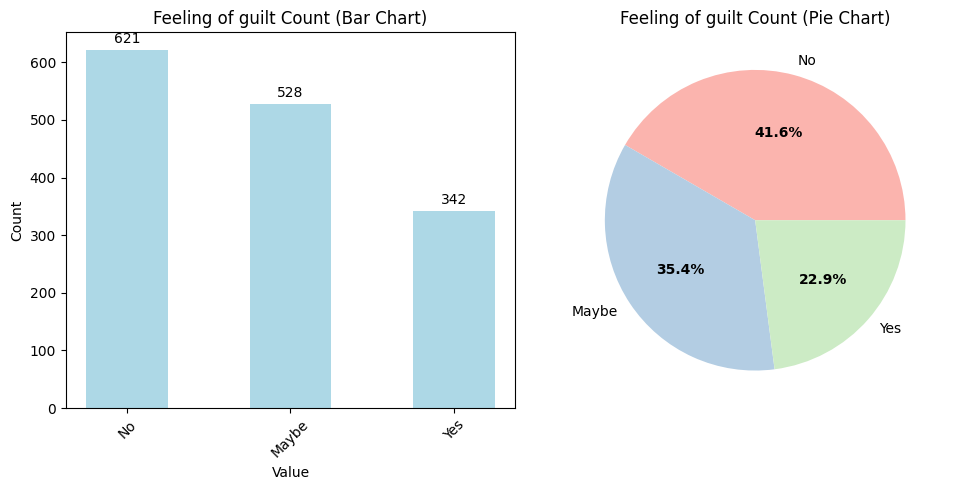

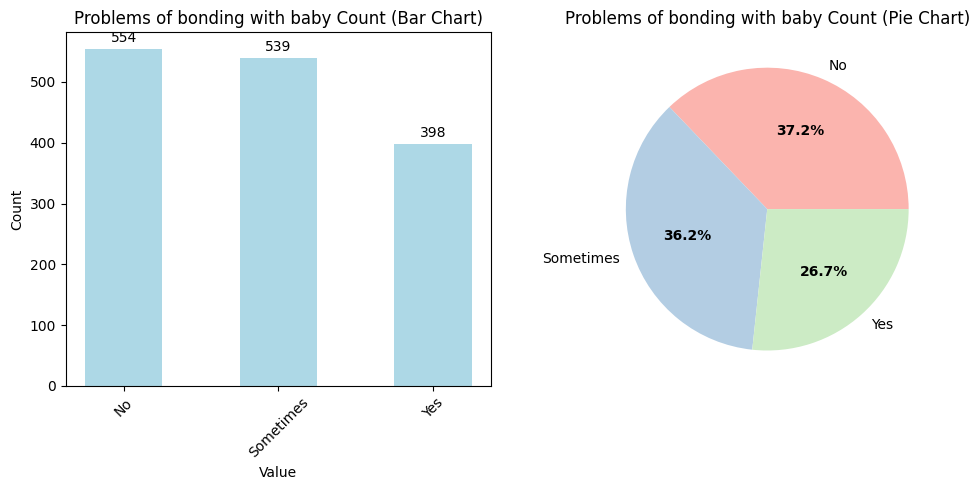

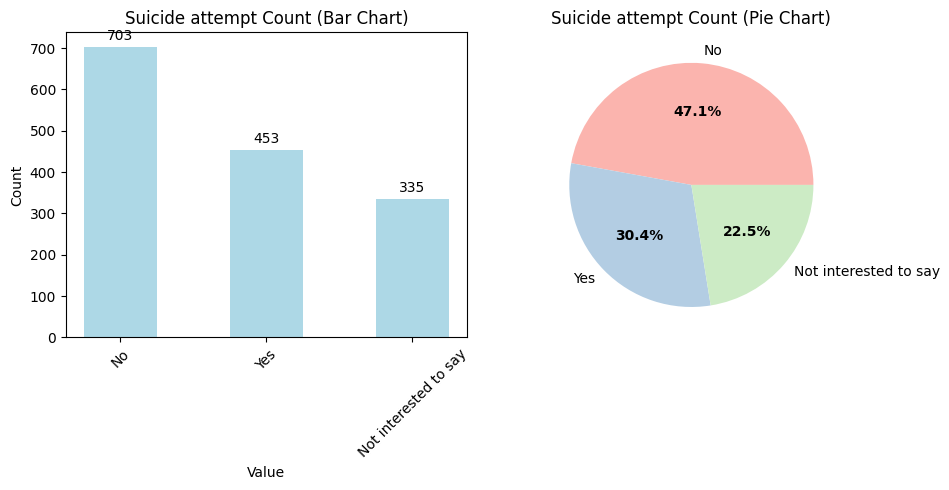

In [7]:
cols = df.columns

# Plot the counts and percentages for each column
for col in cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Smaller figure size

    # Bar chart
    bar_width = 0.5  # Make bars narrower
    bars = axs[0].bar(counts.index, counts.values, color='lightblue', width=bar_width)  # Changed bar color
    axs[0].set_title(f'{col} Count (Bar Chart)')
    axs[0].set_xlabel('Value')
    axs[0].set_ylabel('Count')
    axs[0].tick_params(axis='x', rotation=45)

    for bar in bars:
        height = bar.get_height()
        axs[0].annotate(f'{height}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    # Pie chart
    pie_colors = plt.cm.Pastel1(range(len(counts)))  # Use a colormap for different colors
    wedges, texts, autotexts = axs[1].pie(counts, labels=counts.index.map(str), autopct='%1.1f%%', colors=pie_colors)
    axs[1].set_title(f'{col} Count (Pie Chart)')

    plt.setp(autotexts, size=10, weight="bold")

    plt.tight_layout()
    plt.show()
    print()

# **Data Pre-processing:**

In [8]:
age_mapping = {'25-30': 1,
               '30-35': 2,
               '35-40': 3,
               '40-45': 4,
               '45-50': 5
               }
Irritable_mapping = {
    'Yes': 2,
    'No': 0,
    'Sometimes': 1
}
Conc_mapping = {
    'Yes': 2,
    'No': 0,
    'Often': 1
}
Anxious_mapping = {
    'Yes': 1,
    'No': 0
}
Bonding_mapping = {
    'Yes': 2,
    'No': 0,
    'Sometimes': 1
}

Feeling_mapping = {
    'Yes':2,
    'Sometimes':1,
    'No':0,
}
Sleeping_mapping = {
    'Yes':2,
    'Two or more days a week':1,
    'No':0,
}

Overeating_mapping = {
    'Yes':2,
    'No':1,
    'Not at all':0,
}

Guilt_mapping = {
    'Yes':2,
    'Maybe':1,
    'No':0,
}
Suicide_mapping = {
    'No':0,
    'Yes':1,
    'Not interested to say' :2,
}

df['Age'] = df['Age'].map(age_mapping)
df['Irritable towards baby & partner'] = df['Irritable towards baby & partner'].map(Irritable_mapping)
df['Problems concentrating or making decision'] = df['Problems concentrating or making decision'].map(Conc_mapping)
df['Feeling anxious'] = df['Feeling anxious'].map(Anxious_mapping)
df['Problems of bonding with baby'] = df['Problems of bonding with baby'].map(Bonding_mapping)
df['Feeling sad or Tearful'] = df['Feeling sad or Tearful'].map(Feeling_mapping)
df['Trouble sleeping at night'] = df['Trouble sleeping at night'].map(Sleeping_mapping)
df['Overeating or loss of appetite'] = df['Overeating or loss of appetite'].map(Overeating_mapping)
df['Feeling of guilt'] = df['Feeling of guilt'].map(Guilt_mapping)
df['Suicide attempt'] = df['Suicide attempt'].map(Suicide_mapping)

In [9]:
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,3,2,2,1,2,2,1,0,2,1
1,4,2,0,0,2,2,0,2,2,0
2,3,2,0,2,2,2,1,0,1,0
3,3,2,2,2,2,1,1,1,0,0
4,4,2,0,1,2,1,1,0,2,0


# **Feature Selection**

**1. Co-relation Matrix**





In [10]:
df_corr = df.corr()
todrop = df_corr['Suicide attempt'][df_corr['Suicide attempt']<0.01].index.tolist()
todrop

['Age',
 'Feeling sad or Tearful',
 'Problems concentrating or making decision',
 'Overeating or loss of appetite',
 'Feeling anxious',
 'Problems of bonding with baby']

In [11]:
target = df['Suicide attempt']
features = df.drop(todrop, axis = 1)
features = features.drop(['Suicide attempt'], axis = 1)
features.columns

Index(['Irritable towards baby & partner', 'Trouble sleeping at night',
       'Feeling of guilt'],
      dtype='object')

**2. Recursive Feature Elimination (RFE)**


In [12]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

model = LogisticRegression()
rfe = RFE(estimator=model, n_features_to_select=6)  # Specify the estimator and the number of features
fit = rfe.fit(X, y)

print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))
print("Feature Ranking: %s" % (fit.ranking_))

# Get the selected feature names
selected_features = X.columns[fit.support_]
print(selected_features)



Num Features: 6
Selected Features: [False  True  True  True False  True  True  True False]
Feature Ranking: [4 1 1 1 3 1 1 1 2]
Index(['Feeling sad or Tearful', 'Irritable towards baby & partner',
       'Trouble sleeping at night', 'Overeating or loss of appetite',
       'Feeling anxious', 'Feeling of guilt'],
      dtype='object')


**3. Chi-Square Test**

In [13]:
from sklearn.feature_selection import SelectKBest, chi2


X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

# Apply SelectKBest class to extract top features
bestfeatures = SelectKBest(score_func=chi2, k='all')
fit = bestfeatures.fit(X, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

# Concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Specs', 'Score']  # Naming the dataframe columns
print(featureScores.nlargest(10, 'Score'))  # Print 10 best features


                                       Specs      Score
7                           Feeling of guilt  82.137101
2           Irritable towards baby & partner  80.184377
1                     Feeling sad or Tearful  51.952410
6                            Feeling anxious  45.459321
3                  Trouble sleeping at night  27.562757
4  Problems concentrating or making decision  15.536827
0                                        Age   5.322922
8              Problems of bonding with baby   2.567992
5             Overeating or loss of appetite   1.270242


**4. Tree-based Classifiers**

[0.08680579 0.13175744 0.12448771 0.13416103 0.11131105 0.11116717
 0.06134457 0.12775973 0.1112055 ]


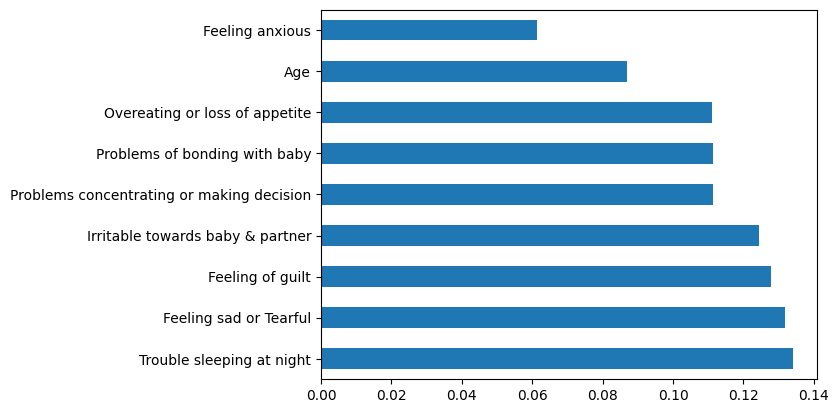

In [14]:
from sklearn.ensemble import ExtraTreesClassifier


X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

model = ExtraTreesClassifier()
model.fit(X, y)
print(model.feature_importances_)  # Use inbuilt class feature_importances of tree-based classifiers

# Plotting feature importances
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()


**5. Lasso Regression**

Best alpha using built-in LassoCV: 0.000142
Best score using built-in LassoCV: 0.169283


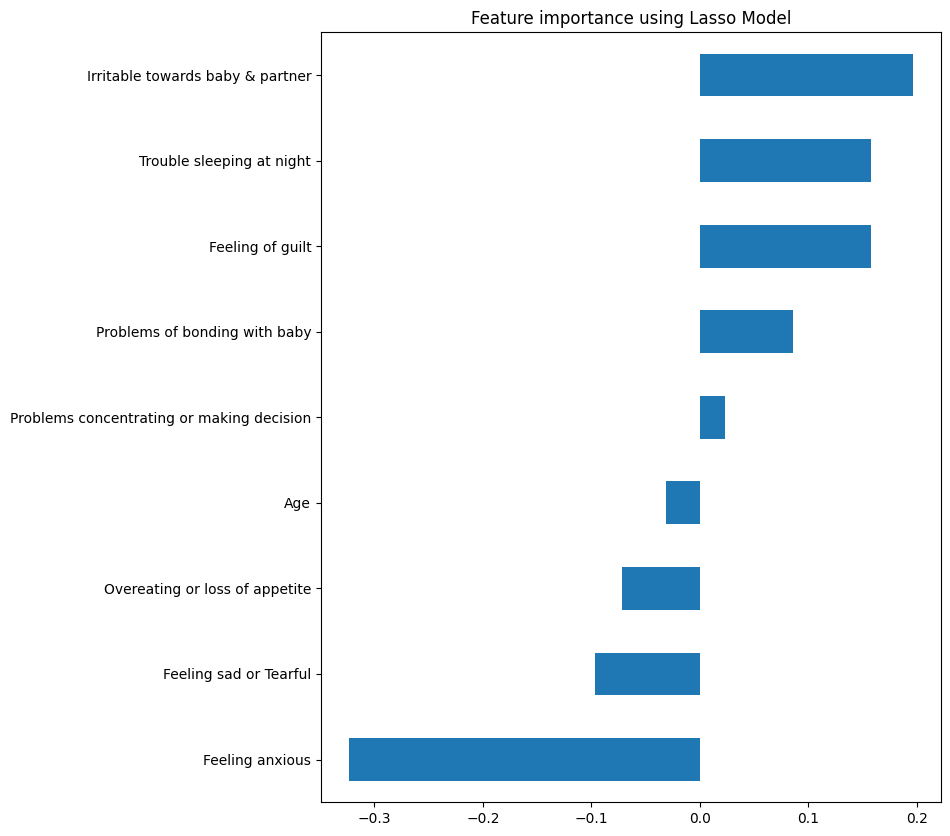

In [15]:
from sklearn.linear_model import LassoCV


X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

# LassoCV for feature selection
lasso = LassoCV()
lasso.fit(X, y)

print("Best alpha using built-in LassoCV: %f" % lasso.alpha_)
print("Best score using built-in LassoCV: %f" % lasso.score(X, y))

# Coefficients
coef = pd.Series(lasso.coef_, index=X.columns)

# Plotting the coefficients
imp_coef = coef.sort_values()
plt.figure(figsize=(8, 10))
imp_coef.plot(kind="barh")
plt.title("Feature importance using Lasso Model")
plt.show()

**6. Random Forest Classifier**

In [16]:
from sklearn.ensemble import RandomForestClassifier
# Features and target variable
X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

# Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by feature importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the feature importance
print(feature_importance_df)

# Optionally, you can select the top N features
top_n = 6
top_features = feature_importance_df.head(top_n)
print(f"\nTop {top_n} features:")
print(top_features)

                                     Feature  Importance
2           Irritable towards baby & partner    0.128187
3                  Trouble sleeping at night    0.127746
1                     Feeling sad or Tearful    0.126459
7                           Feeling of guilt    0.121454
8              Problems of bonding with baby    0.117932
5             Overeating or loss of appetite    0.114281
4  Problems concentrating or making decision    0.106306
0                                        Age    0.097382
6                            Feeling anxious    0.060253

Top 6 features:
                            Feature  Importance
2  Irritable towards baby & partner    0.128187
3         Trouble sleeping at night    0.127746
1            Feeling sad or Tearful    0.126459
7                  Feeling of guilt    0.121454
8     Problems of bonding with baby    0.117932
5    Overeating or loss of appetite    0.114281


# **MODEL**

In [17]:
print(df.columns)


Index(['Age', 'Feeling sad or Tearful', 'Irritable towards baby & partner',
       'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')


In [18]:
X = df[['Irritable towards baby & partner',
        'Problems concentrating or making decision',
        'Feeling sad or Tearful',
        'Feeling of guilt',
        'Trouble sleeping at night',
        'Overeating or loss of appetite']]

y = df['Suicide attempt']



## **Decision Tree**

Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       140
           1       0.90      0.93      0.91        86
           2       0.90      0.89      0.90        73

    accuracy                           0.92       299
   macro avg       0.91      0.92      0.92       299
weighted avg       0.92      0.92      0.92       299



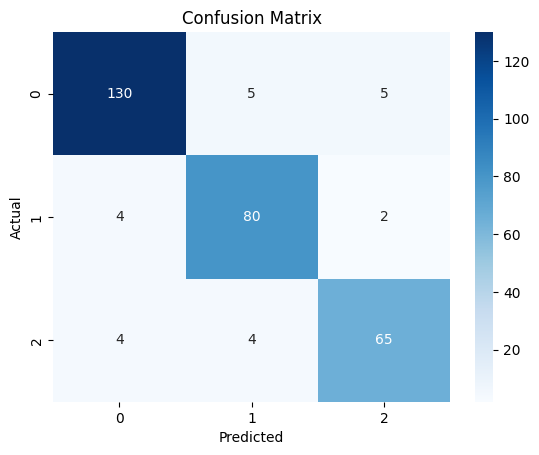

In [19]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the decision tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Random Forest Classifier

Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       140
           1       0.90      0.93      0.91        86
           2       0.88      0.89      0.88        73

    accuracy                           0.91       299
   macro avg       0.91      0.91      0.91       299
weighted avg       0.91      0.91      0.91       299



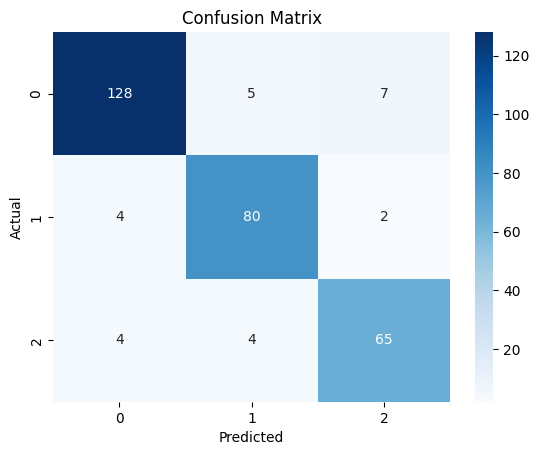

In [20]:
from sklearn.ensemble import RandomForestClassifier



# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the random forest classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {accuracy_rf:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Naive Bayes

Accuracy: 0.60
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       140
           1       0.52      0.55      0.53        86
           2       0.67      0.41      0.51        73

    accuracy                           0.60       299
   macro avg       0.60      0.56      0.57       299
weighted avg       0.60      0.60      0.59       299



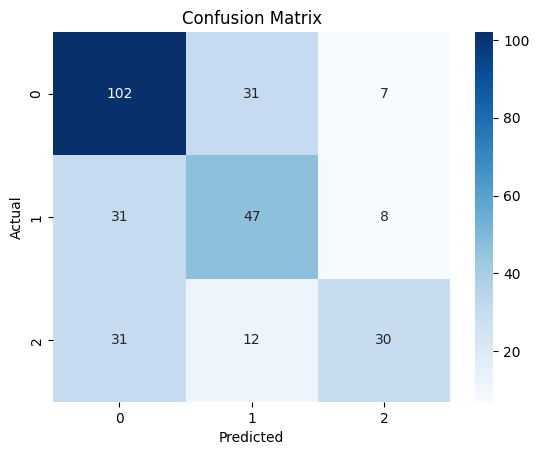

In [21]:
from sklearn.naive_bayes import GaussianNB


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Naive Bayes classifier
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_nb = nb_clf.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy: {accuracy_nb:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_nb))

# Confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Gradient Boosting

Accuracy: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       140
           1       0.73      0.73      0.73        86
           2       0.72      0.66      0.69        73

    accuracy                           0.76       299
   macro avg       0.75      0.74      0.74       299
weighted avg       0.75      0.76      0.75       299



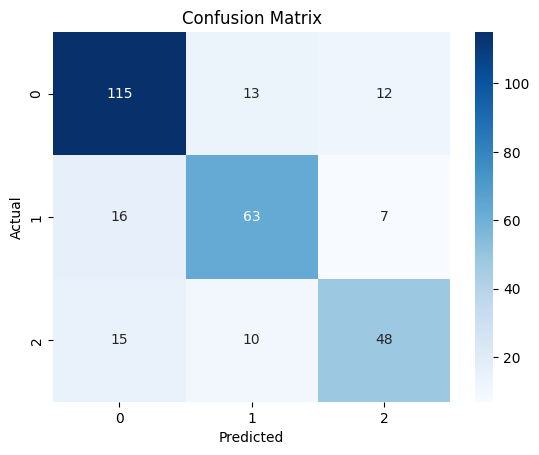

In [22]:
from sklearn.ensemble import GradientBoostingClassifier



# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_clf.predict(X_test)

# Evaluate the model
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f'Accuracy: {accuracy_gb:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_gb))

# Confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## KNN

Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       140
           1       0.84      0.90      0.87        86
           2       0.85      0.75      0.80        73

    accuracy                           0.85       299
   macro avg       0.85      0.84      0.84       299
weighted avg       0.85      0.85      0.85       299



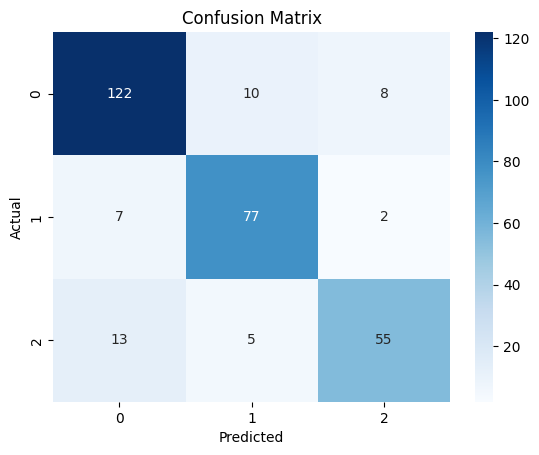

In [23]:
# KNN

from sklearn.neighbors import KNeighborsClassifier


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the K-Nearest Neighbors classifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn_clf.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy_knn:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## SVM

Accuracy: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       140
           1       0.75      0.74      0.75        86
           2       0.76      0.73      0.74        73

    accuracy                           0.79       299
   macro avg       0.78      0.78      0.78       299
weighted avg       0.79      0.79      0.79       299



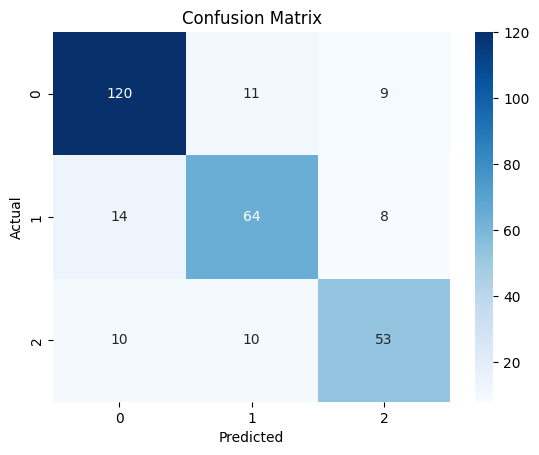

In [24]:
from sklearn.svm import SVC


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Support Vector Machines classifier
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_svm = svm_clf.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy: {accuracy_svm:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Neural Network

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       140
           1       0.69      0.60      0.65        86
           2       0.60      0.52      0.56        73

    accuracy                           0.69       299
   macro avg       0.67      0.65      0.66       299
weighted avg       0.69      0.69      0.69       299



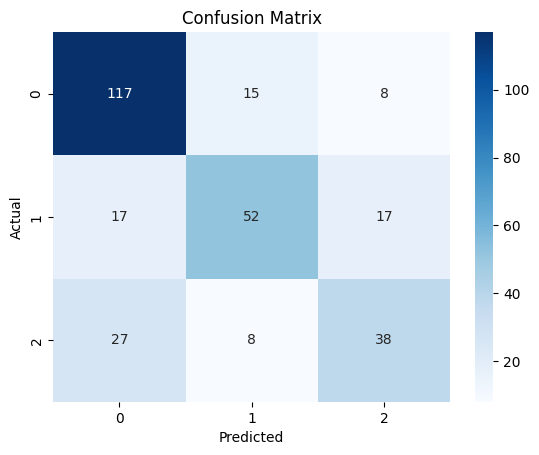

In [25]:
# Neural Networks

from sklearn.neural_network import MLPClassifier


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Neural Network classifier
nn_clf = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=500, random_state=42)
nn_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_nn = nn_clf.predict(X_test)

# Evaluate the model
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f'Accuracy: {accuracy_nn:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred_nn))

# Confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
<ipython-input-34-9add2a57f50f>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=results_df, palette='viridis', ax=axes[idx])
<ipython-input-34-9add2a57f50f>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=results_df, palette='viridis', ax=axes[idx])
<ipython-input-34-9add2a57f50f>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variabl

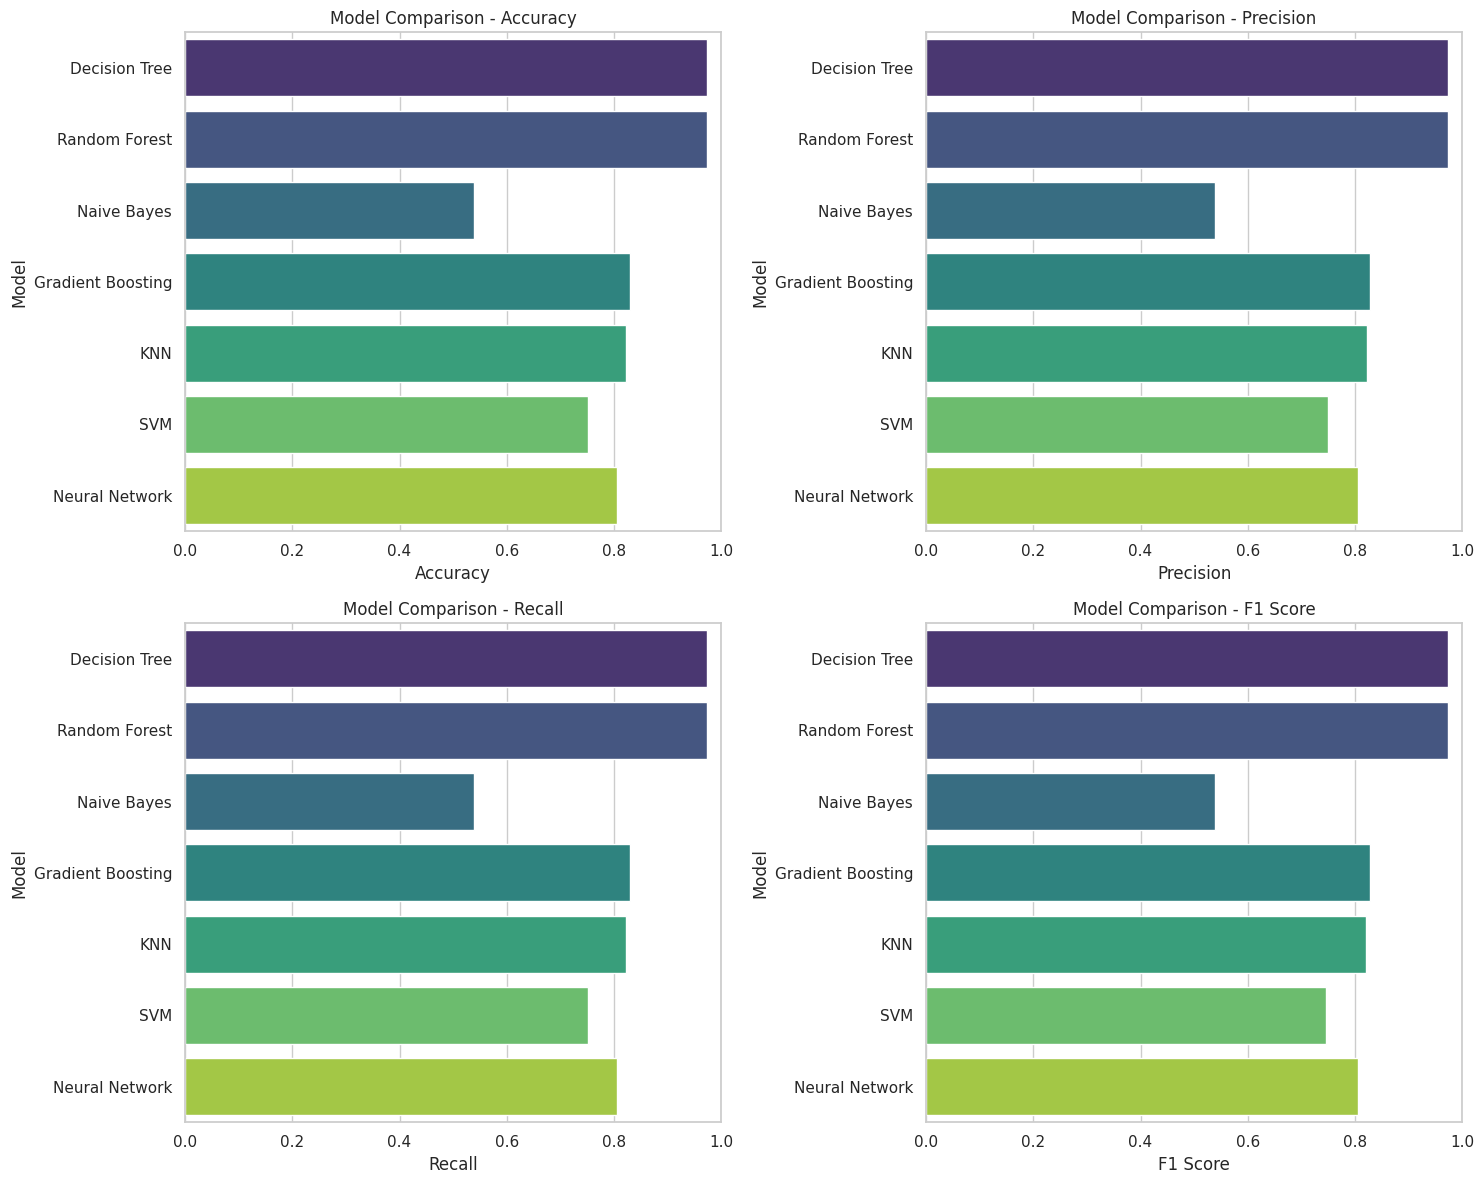

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Sample data preparation
# Assuming df is your DataFrame and 'Suicide attempt' is the target column
X = df.drop('Suicide attempt', axis=1)
y = df['Suicide attempt']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Neural Network': MLPClassifier()
}

# Train and evaluate the models
results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plot the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    sns.barplot(x=metric, y='Model', data=results_df, palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'Model Comparison - {metric}')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()



